### Generate SIMLIB file for SNANA with specific sky location from GW skymap

In [1]:
import opsimsummaryv2 as opsim
import pandas as pd
import numpy as np
import healpy as hp
# import ligo.skymap functions
import ligo.skymap.plot
from ligo.skymap.io.fits import read_sky_map
from ligo.skymap.moc import uniq2nest, uniq2pixarea
import ligo.skymap.postprocess as postprocess
# import astropy functions
from astropy.coordinates import SkyCoord
from astropy.cosmology import Planck18 as cosmo
from astropy import units as u
from astropy.cosmology import z_at_value
from matplotlib import pyplot as plt

/fred/oz016/bgao_kn/rubin/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/fred/oz016/bgao_kn/rubin/lib/python3.10/site-packages/ligo/lw/lsctables.py:89: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


Select several sky positions from GW skymap

In [2]:
class MyOpsimSurvey(opsim.OpSimSurvey):
    def sample_coordinates(self,
                           ra,
                           dec,
                           redshift=None,
                           nsides=256,
                           is_deg=True,
                           nworkers=10):
        """
        Get healpy pixel indices for given RA and Dec coordinates. And select these healpy pixels as fields.
        Parameters
        ----------
        ra : numpy.ndarray(float)
            RA coordinates
        dec : numpy.ndarray(float)
            Dec coordinates
        redshift : numpy.ndarray(float), optional
            Redshift of the fields, by default None;if provided, redshift will be added to survey dataframe
            and be written to LIBID header in SIMLIB files.
        nsides : int, optional
            Healpy nside used to compute pixel indices, by default 256
        is_deg : bool, optional
            are RA, Dec given in degrees, by default True
        nworkers : int, optional
            Number of cores used to run multiprocessing on host matching, by default 10
        """

        N_fields = len(ra)
        if len(ra) > len(self.hp_rep):
            raise ValueError(
                f"N_fields ({len(ra)}) > survey fields ({len(self.hp_rep)})"
            )
        
        if is_deg:
            phi = np.radians(ra)
            theta = np.radians(90.0-dec)

        pix = hp.ang2pix(nsides, theta, phi)    # nest=False
        self._survey = self.hp_rep[self.hp_rep.index.isin(pix)].copy()
        if redshift is not None:
            self._survey['redshift'] = redshift[np.isin(pix, self._survey.index)].copy()
        self._survey.reset_index(inplace=True)
        self._survey.attrs = self.hp_rep.attrs.copy()
        self._survey.attrs["N_fields"] = N_fields

        if self.host is not None:
            print("Compute survey hosts")
            self._survey_hosts = self.get_survey_hosts(nworkers=nworkers)
    

In [3]:
sim_id = 6
# MOC skymap for high resolution
skymap = read_sky_map(f'/fred/oz016/bgao_kn/data/bns_skymap/{sim_id}.fits', moc=True)
# Load with nest map
nest_map, meta = read_sky_map(f'/fred/oz016/bgao_kn/data/bns_skymap/{sim_id}.fits', nest=True)
distmean = meta.get('distmean')
diststd = meta.get('diststd')
print("Distance mean:", meta.get('distmean'), "Mpc\nDistance std:", meta.get('diststd'), 'Mpc')
skymap[:5]

Distance mean: 613.5378306750999 Mpc
Distance std: 207.6096169175938 Mpc


UNIQ,PROBDENSITY,DISTMU,DISTSIGMA,DISTNORM
,1 / sr,Mpc,Mpc,1 / Mpc2
int64,float64,float64,float64,float64
1024,3.0149809450637874e-05,342.1529339888736,395.11906866189776,3.884067583127525e-06
1025,2.3112109380115745e-05,324.72294779799995,413.00456237012463,3.910629070567796e-06
1026,0.003064224602111363,344.3217899176964,257.81255245410193,5.472498341264127e-06
1027,2.4842884892086737e-05,213.78531218490258,467.7912264272031,4.655290277241597e-06
1028,5.746089183533391e-05,108.2321960650648,440.0148534250174,7.089989674642782e-06


distmu: -300.6063398740389
distsigma: 486.3639839497842
distnorm: 2.530748331729813e-05
r_peak: 553.7500188634634
555.5555555555555 0.0013607044982638056


Text(0.5, 1.0, 'Conditional Distance PDF')

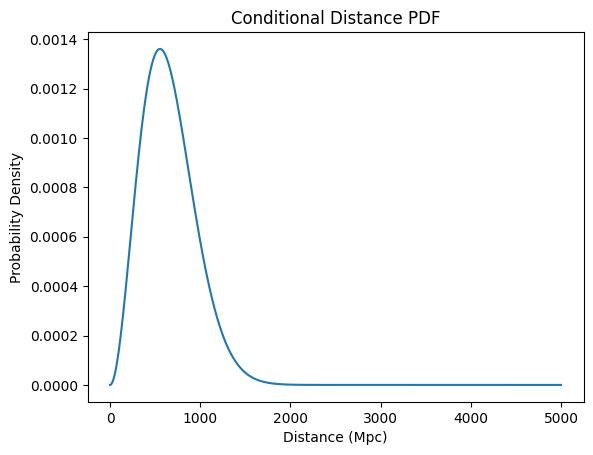

In [4]:
# show conditional distance pdf for a random pixel

from ligo.skymap.distance import conditional_pdf
def r_peak(distmu, distsigma):
    distmu = np.asarray(distmu, dtype=float)
    distsigma = np.asarray(distsigma, dtype=float)
    return 0.5 * (distmu + np.sqrt(distmu**2 + 8.0 * distsigma**2))

i = np.random.choice(np.where(skymap['DISTMU']<0)[0])
distmu = skymap['DISTMU'][i]
distsigma = skymap['DISTSIGMA'][i]
distnorm = skymap['DISTNORM'][i]
print("distmu:", distmu)
print("distsigma:", distsigma)
print("distnorm:", distnorm)
r = np.linspace(0, 5000, 1000)
pdf = conditional_pdf(r, distmu, distsigma, distnorm)
r_peak = r_peak(distmu, distsigma)
print("r_peak:", r_peak)
print(r[np.argmax(pdf)], pdf[np.argmax(pdf)])
plt.plot(r, pdf)
plt.xlabel('Distance (Mpc)')
plt.ylabel('Probability Density')
plt.title('Conditional Distance PDF')

In [5]:
# function to sample sky coordinates from MOC skymap
def r_peak(distmu, distsigma):
    """
    Calculate the peak distance from distmu and distsigma.(ansatz distribution)
    Note: (distnorm does not affect the peak position)
    """
    distmu = np.asarray(distmu, dtype=float)
    distsigma = np.asarray(distsigma, dtype=float)
    return 0.5 * (distmu + np.sqrt(distmu**2 + 8.0 * distsigma**2))

def sample_sky_from_moc(mocmap, level=0.9, within=True):
    """
    Sample sky coordinates from a MOC skymap within/without a credible level.
    """
    uniq = mocmap['UNIQ']
    probdensity = mocmap['PROBDENSITY']
    distmu = mocmap['DISTMU']
    distsigma = mocmap['DISTSIGMA']

    # 1) UNIQ -> order, ipix, nside
    order, ipix = uniq2nest(uniq)

    # 2) caculate pixel area
    dA = uniq2pixarea(uniq)
    # 3) calculate pixel probability
    dP = probdensity * dA
    # 4) calculate credible levels
    cls = postprocess.find_greedy_credible_levels(
        dP, probdensity
    )
    cls = np.where(cls>1, 1.0, cls)

    if within:
        mask = cls <= level
        dP_cred = dP[mask]
        order_cred = order[mask]
        ipix_cred = ipix[mask]
    else:
        mask = cls >= level
        dP_cred = dP[mask]
        order_cred = order[mask]
        ipix_cred = ipix[mask]


    # 5) calculate RA, Dec for sampled pixels
    ras  = np.empty(len(dP_cred), dtype=float)
    decs = np.empty(len(dP_cred), dtype=float)

    # group by order to speed up
    for k in np.unique(order_cred):
        m = (order_cred == k)
        this_ipix  = ipix_cred[m]
        this_nside = 2 ** k
        theta, phi = hp.pix2ang(this_nside, this_ipix, nest=True)
        ras[m]  = np.degrees(phi)
        decs[m] = 90.0 - np.degrees(theta)
    
    # calculate distance with peak pdf from distmu and distsigma
    distmu = np.array(distmu[mask], dtype=float)
    distsigma = np.array(distsigma[mask], dtype=float)
    dist_peak = r_peak(distmu, distsigma)

    return ras, decs, dist_peak

In [6]:
ra, dec, dist_peak = sample_sky_from_moc(skymap, level=0.9, within=True)
redshift = z_at_value(cosmo.luminosity_distance, dist_peak * u.Mpc).value

print("Sampled RA:", ra)
print("Sampled Dec:", dec)
print("Sampled redshifts:", redshift)
print("Number of sampled pixels:", len(ra))

Sampled RA: [ 32.34375     30.9375      25.3125     ... 167.16796875 166.81640625
 166.9921875 ]
Sampled Dec: [ 14.47751219  20.74237995  18.20995686 ... -28.63098984 -28.63098984
 -28.46113309]
Sampled redshifts: [0.12348863 0.1268146  0.12985995 ... 0.14322722 0.14326819 0.14332825]
Number of sampled pixels: 15554


In [8]:
# plot functions
def add_edges():
    hp.graticule(verbose=False)
    plt.grid(True)
    lons = np.arange(-150.0,210,30.0)
    lats = np.zeros(lons.shape)
    for lon, lat in zip(lons,lats):
        hp.projtext(lon,lat,"%.0f"%lon,lonlat=True, size=18)
    lats = np.arange(-60.0,90,30.0)
    lons = np.zeros(lons.shape)
    for lon, lat in zip(lons,lats):
        hp.projtext(lon,lat,"%.0f"%lat,lonlat=True, size=18)

def add_contour(moc_map, level=[90], fig=None):

    from astropy.table import Table
    from matplotlib import rcParams

    dA = uniq2pixarea(moc_map["UNIQ"])
    dP = moc_map["PROBDENSITY"] * dA
    cls = 100 * postprocess.find_greedy_credible_levels(
        dP, moc_map["PROBDENSITY"]
    )
    table = Table({"UNIQ": moc_map["UNIQ"], "CLS": cls})
    cs = ax.contour_hpx(
        (table, "ICRS"),
        colors="k",
        linewidths=0.5,
        levels=level,
        order="nearest-neighbor",
    )
    fmt = r"%g\%%" if rcParams["text.usetex"] else "%g%%"
    plt.clabel(cs, fmt=fmt, fontsize=6, inline=True)

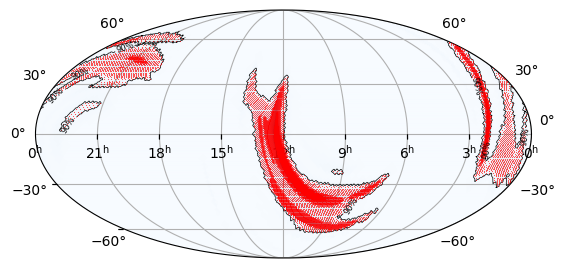

In [9]:
ax = plt.figure().add_subplot(111, projection="astro mollweide")
# plot 90% contour
add_contour(skymap, level=[90], fig=ax)
# plot skymap
ax.imshow_hpx((skymap, "ICRS"), vmin=0, order="nearest-neighbor", cmap='Blues')
for ra_, dec_, z in zip(ra, dec, redshift):
    ax.plot_coord(
        SkyCoord(ra_, dec_, unit=u.deg),
        "*",
        markerfacecolor="red",
        markeredgecolor="red",
        markersize=0.1,
    )
add_edges()

In [10]:
OpSimSurv = opsim.OpSimSurvey("/fred/oz016/bgao_kn/data/rubin_sim/baseline/baseline_v5.0.1_10yrs.db")

Reading from database sqlite:////fred/oz016/bgao_kn/data/rubin_sim/baseline/baseline_v5.0.1_10yrs.db


Read N = 2092088 observations in 182.05 seconds.
No host file.


Finished compute healpy representation, total number of fields : 535248.


/fred/oz016/bgao_kn/rubin/lib/python3.10/site-packages/healpy/visufunc.py:1504: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  ax.graticule(dpar=dpar, dmer=dmer, coord=coord, local=local, **kwds)


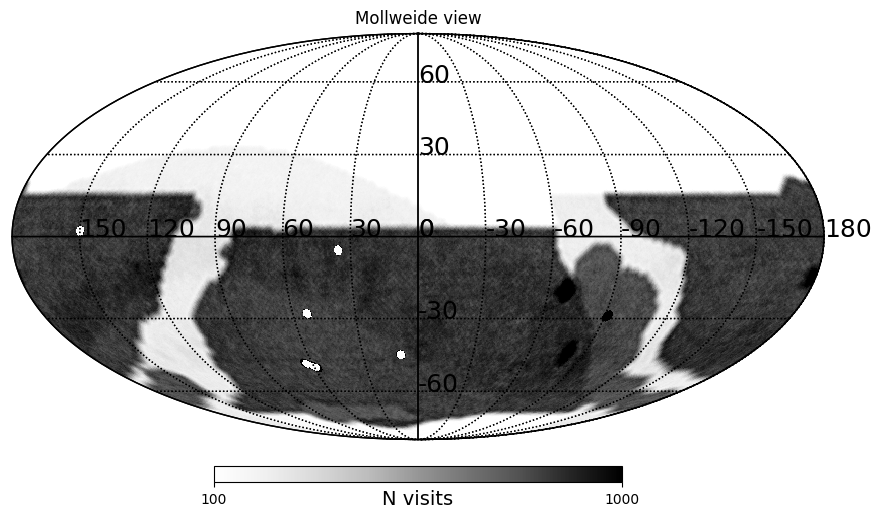

In [11]:
# Compute the healpy representation of the survey
# with a cut to a minimum of 500 and a maximum of 10000 visits
nsides = 256
OpSimSurv.compute_hp_rep(nside=nsides, minVisits=1, maxVisits=10000)    # nest=False

# Plot the healpy configuration
fig = OpSimSurv.plot_hp_rep(min=100, max=1000, cmap="Grays")
hp.graticule()
add_edges()

In [12]:
hp_rep = OpSimSurv.hp_rep
hp_rep

,hp_ra,hp_dec,n_visits,field_label
ipix,,,,
161529,1.530913,0.629254,1,WFD
161530,1.537049,0.629254,1,WFD
161531,1.543185,0.629254,1,WFD
161532,1.549321,0.629254,3,WFD
161533,1.555457,0.629254,2,WFD
...,...,...,...,...
786427,5.890486,-1.564417,97,WFD
786428,0.785398,-1.567607,108,WFD
786429,2.356194,-1.567607,113,WFD


In [13]:
phi = np.radians(ra)
theta = np.radians(90.0-dec)
pix = hp.ang2pix(nsides, theta, phi)

targets_hp = hp_rep[hp_rep.index.isin(pix)].reindex(pix).copy()
targets_hp.dropna(how='all', inplace=True)
targets_hp['redshift'] = redshift[np.isin(pix, targets_hp.index)].copy()
targets_hp

,hp_ra,hp_dec,n_visits,field_label,redshift
ipix,,,,,
294492,0.567573,0.252680,202.0,WFD,0.123489
253528,0.543029,0.362023,184.0,WFD,0.126815
269896,0.444854,0.317824,189.0,WFD,0.129860
228948,0.518486,0.429775,14.0,WFD,0.128709
597528,0.150330,-0.547827,870.0,WFD,0.091714
...,...,...,...,...,...
582618,2.908428,-0.502674,898.0,WFD,0.143167
582619,2.914563,-0.502674,898.0,WFD,0.143134
581595,2.917631,-0.499705,893.0,WFD,0.143227


/fred/oz016/bgao_kn/rubin/lib/python3.10/site-packages/healpy/visufunc.py:1504: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  ax.graticule(dpar=dpar, dmer=dmer, coord=coord, local=local, **kwds)


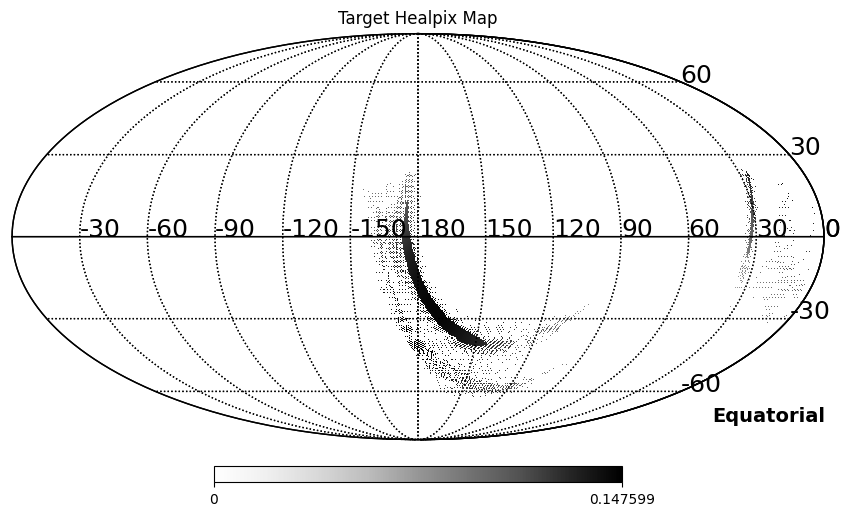

In [15]:
ipix_map = np.zeros(hp.nside2npix(nsides))
# ipix_map[pix] = (100 * redshift).astype(int)
ipix_map[targets_hp.index.values] = redshift[np.isin(pix, targets_hp.index)].copy()
hp.mollview(ipix_map, rot=180, title="Target Healpix Map", cmap='Grays', coord='C')
hp.graticule()
add_edges()

In [16]:
OpSimSurv.sample_coordinates(ra, dec, redshift, nsides=nsides, is_deg=True)

In [17]:
# Writing simlib
sim = opsim.sim_io.SNANA_Simlib(OpSimSurv, out_path='/fred/oz016/bgao_kn/data/simlib/', file_suffix="_test")
sim.write_SIMLIB()

Writing SIMLIB in /fred/oz016/bgao_kn/data/simlib/baseline_v5.0.1_10yrs_test.SIMLIB
SIMLIB wrote in 71.26 sec.



In [23]:
redshift

array([0.12348863, 0.1268146 , 0.12985995, ..., 0.14322722, 0.14326819,
       0.14332825])

In [28]:
i = np.argmin(np.abs(redshift-0.126815))
print(i, ra[i], dec[i])

1 30.937499999999996 20.742379954487134
